# Construction of mixed-dimensional grids

In [159]:
import numpy as np
import porepy as pp

In [160]:
mins = np.array([0.,0.,0.])
maxs = np.array([10.,10.,10.])

In [161]:
bounding_box = {'xmin': mins[0], 'xmax': maxs[0], 'ymin': mins[1], 'ymax': maxs[1], 'zmin': mins[2], 'zmax': maxs[2]}
domain = pp.Domain(bounding_box=bounding_box)
domain

pp.Domain(bounding_box={'xmin': np.float64(0.0), 'xmax': np.float64(10.0), 'ymin': np.float64(0.0), 'ymax': np.float64(10.0), 'zmin': np.float64(0.0), 'zmax': np.float64(10.0)})

In [162]:
nfracs = 10
r_range = np.array([2,8])
f_i = np.array([])
for i in range(nfracs):
    center = np.random.rand(3) * (maxs - mins) + mins
    major_axis = np.random.rand() * (r_range[1] - r_range[0]) + r_range[0]
    minor_axis = frac_major.copy() #circular
    major_axis_angle = 0. #for circular
    strike_angle = np.random.rand() * np.pi - np.pi/2
    dip_angle = np.random.rand() * np.pi - np.pi/2
    f_i = np.append(f_i,pp.create_elliptic_fracture(center, major_axis, minor_axis, major_axis_angle, strike_angle, dip_angle))

In [163]:
network = pp.create_fracture_network(fractures=f_i,domain=None)
network

Three-dimensional fracture network with 10 plane fractures.

In [164]:
mesh_args = {'cell_size_boundary': 1.0, 'cell_size_fracture': 0.5, 'cell_size_min': 0.2}
mdg = pp.create_mdg("simplex", mesh_args, network)
mdg

Mixed-dimensional grid containing 23 grids and 34 interfaces.
Maximum dimension present: 3 
Minimum dimension present: 1 
1 grids of dimension 3 with in total 167706 cells
10 grids of dimension 2 with in total 9859 cells
12 grids of dimension 1 with in total 122 cells
10 interfaces between grids of dimension 3 and 2 with in total 19718 mortar cells.
24 interfaces between grids of dimension 2 and 1 with in total 488 mortar cells.

In [165]:
mdg2d = mdg.copy()
for sd in mdg2d.subdomains():
    if sd.dim == 3:
        mdg2d.remove_subdomain(sd)
mdg2d

Mixed-dimensional grid containing 22 grids and 24 interfaces.
Maximum dimension present: 2 
Minimum dimension present: 1 
10 grids of dimension 2 with in total 9859 cells
12 grids of dimension 1 with in total 122 cells
24 interfaces between grids of dimension 2 and 1 with in total 488 mortar cells.

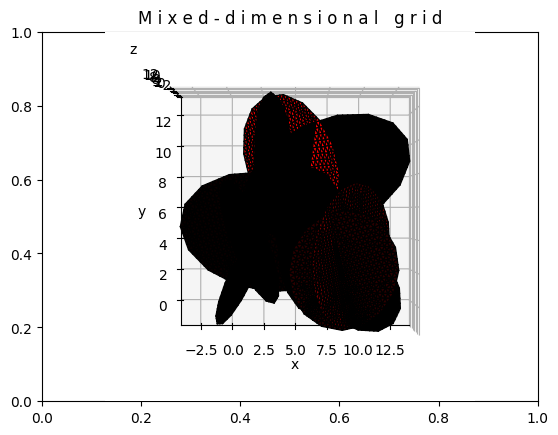

In [166]:
pp.plot_grid(mdg2d, figsize=(12,12), plot_2d=False)

In [ ]:
pp.Exporter(mdg2d, 'mixed_dimensional_grid').write_vtu()